In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys
import numpy as np

In [2]:
TEXT2VQL_ROOT = os.path.abspath(os.getcwd())

while True:
    if os.path.basename(TEXT2VQL_ROOT) == "Text2VQL":
        break
    new = os.path.dirname(TEXT2VQL_ROOT)
    if new == TEXT2VQL_ROOT:
        raise FileNotFoundError("Could not find a parent directory named 'Text2VQL'.")
    TEXT2VQL_ROOT = new

# Process data

In [3]:
def test_dataset():    
    data = []

    llms = ["LLM_A", "LLM_B"]
    finetune_flags = [False, True]
    cases = list(range(1, 20))
    domains = ["text2vql", "railway", "dlt", "cps"]
    langs = ["java", "vql"]

    np.random.seed(42)
    for llm in llms:
        for caseid in cases:
            for finetune in finetune_flags:
                for lang in langs:
                    for shotid in range(1, 6):
                        syntax_ok = np.random.choice([True, False], p=[0.8, 0.2])
                        semantics_ok = np.random.choice([True, False], p=[0.7, 0.3]) if syntax_ok else False
                        data.append({
                            "llm": llm,
                            "finetune": finetune,
                            "caseid": caseid,
                            "domain": np.random.choice(domains),
                            "lang": lang,
                            "shotid": shotid,
                            "query": f"SELECT * FROM table_{caseid}_shot_{shotid};",
                            "syntax": syntax_ok,
                            "diagnostics": None,
                            "semantics": semantics_ok,
                            "idicator": None
                        })

    return pd.DataFrame(data)

In [4]:
def classify(row):
    # Use pd.isna() to handle missing values
    if pd.isna(row["syntax"]) or not row["syntax"]:
        return "Syntax Error"
    elif pd.isna(row["semantics"]) or not row["semantics"]:
        return "Semantic Error"
    else:
        return "Correct"

In [5]:
dtype_mapping = {
    "id": "Int64",
    "llm": str,
    "finetune": "boolean",
    "caseid": "Int64",
    "domain": str,
    "lang": str,
    "shotid": "Int64",
    "query": str,
    "syntax": "boolean",
    "diagnostics": str,
    "semantics": "boolean",
    "idicator": str
}

with sqlite3.connect(os.path.join(TEXT2VQL_ROOT,'finetuning/evaluation.db')) as conn:
    prompts = pd.read_sql_query("SELECT * FROM evaluation", conn)

    for col, dtype in dtype_mapping.items():
        if dtype == "Int64":
            prompts[col] = pd.to_numeric(prompts[col], errors="coerce").astype("Int64")
        elif dtype == "boolean":
            # Coerce non-boolean to NaN
            prompts[col] = prompts[col].map(lambda x: bool(x) if x in [0, 1, True, False] else pd.NA).astype("boolean")
        elif dtype == str:
            prompts[col] = prompts[col].astype(str, errors="ignore")  # keep invalid as string

    prompts["category"] = prompts.apply(classify, axis=1)

print(prompts.dtypes)


id               Int64
llm             object
finetune       boolean
caseid           Int64
domain          object
lang            object
shotid           Int64
query           object
syntax         boolean
diagnostics     object
semantics      boolean
idicator        object
category        object
dtype: object


In [6]:
def loadTruth(path='../dataset_construction/test_metamodel/truth.csv'):
    df = pd.read_csv(
            path,
            encoding='unicode_escape',
            converters={
                "construct_vql": lambda x: {s.strip() for s in str(x).split(",") if s.strip()}
            }
    )

    # Convert 'id' to int and drop rows where it's missing or invalid
    df["id"] = pd.to_numeric(df["id"], errors="coerce")
    df = df.dropna(subset=["id"])
    df["id"] = df["id"].astype(int)
    return df
truth = loadTruth()

# Feature difficulty

In [7]:
def difficulty(ax, data=prompts, categorization=truth, llm='Qwen/Qwen2.5-Coder-1.5B', finetune=1, lang='ocl', colors = {"Syntax Error": "#e74c3c", "Semantic Error": "#f39c12", "Correct": "#27ae60"}):
    df = data[(data['llm']==llm) & (data['finetune']==finetune) & (data['lang']==lang)].merge(categorization, left_on='caseid', right_on='id')
    df = df.explode('construct_vql')
    result = (
        df.groupby(['construct_vql', 'category'])
            .size()
            .unstack(fill_value=0)  # create columns per category
            .reset_index()
            .rename(columns={'construct_vql': 'feature'})
    )
    category_cols = result.columns.drop('feature')  # all category columns

    result_pct = result.copy()
    result_pct[category_cols] = result_pct[category_cols].div(result_pct[category_cols].sum(axis=1), axis=0) * 100

    df =  result_pct.copy()
    df.set_index('feature', inplace=True)

    for cat in ['Syntax Error', 'Semantic Error', 'Correct']:
        if cat not in df.columns:
            df[cat] = 0
    
    df[['Syntax Error','Semantic Error','Correct']].plot(
        ax = ax,
        kind='bar',
        stacked=True,
        color=[colors['Syntax Error'], colors['Semantic Error'], colors['Correct']]
    )

    # Labeling
    ax.set_title(f"{llm} (finetune: {finetune}, language: {lang})")
    ax.set_xlabel('Feature')
    ax.set_ylabel('Category %')
    ax.legend(title='Category')


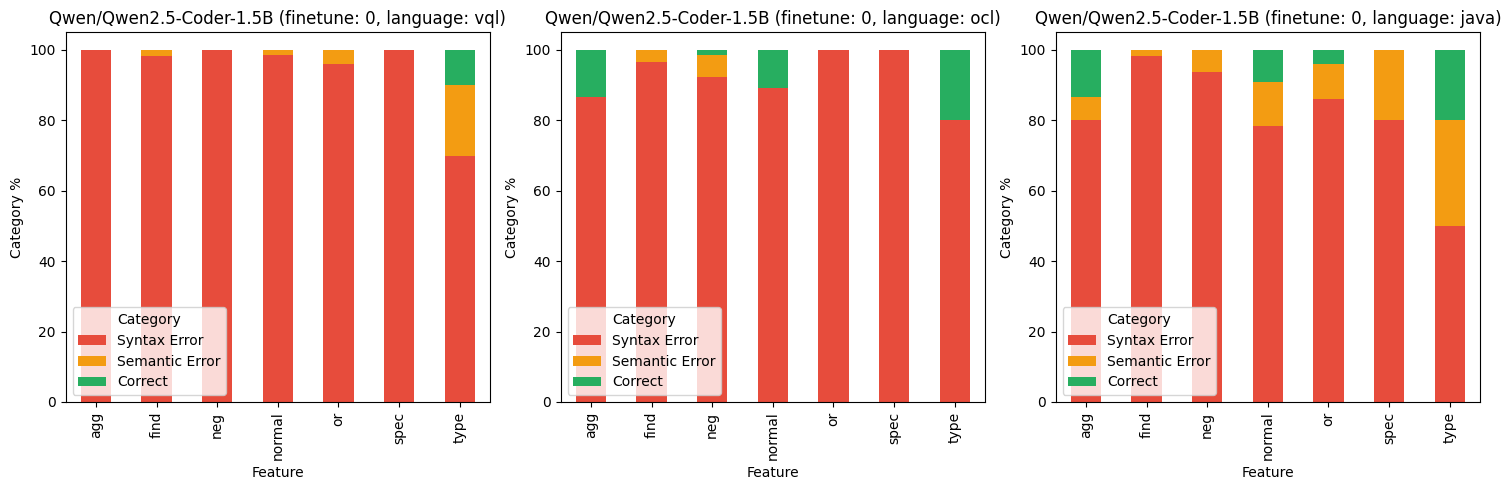

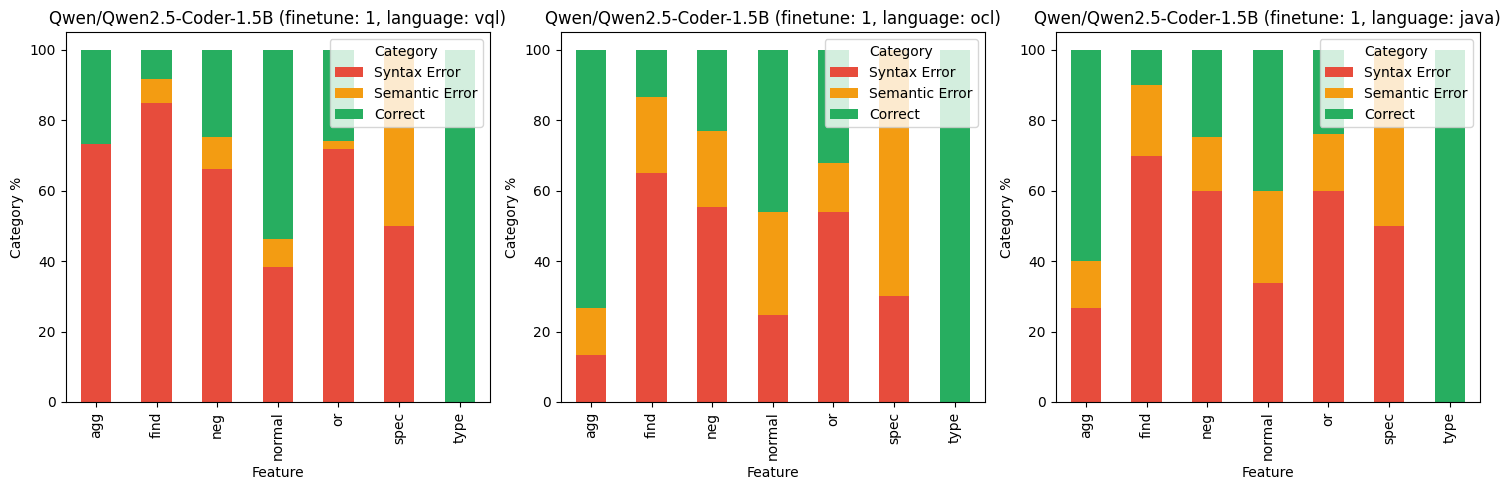

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns

for ax, lang in zip(axs, ['vql', 'ocl', 'java']):
    difficulty(ax, finetune=0, lang=lang)

plt.tight_layout()
#fig.suptitle("Feature difficulty")
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns

for ax, lang in zip(axs, ['vql', 'ocl', 'java']):
    difficulty(ax, finetune=1, lang=lang)

plt.tight_layout()
#fig.suptitle("Feature difficulty")
plt.show()

## Correctness

In [9]:
results = (
    prompts.groupby(["llm", "finetune", "caseid", "category", "lang"])
    .size()
    .reset_index(name="count")
)
results["finetune"] = results["finetune"].map({True: "Finetuned", False: "In context"})
totals = results.groupby(["llm", "finetune"])["count"].transform("sum")
results["x_label"] = results["caseid"].astype(str) + " - " + results["finetune"]

In [10]:
results

,llm,finetune,caseid,category,lang,count,x_label
0,ChatGPT,In context,0,Correct,java,5,0 - In context
1,ChatGPT,In context,0,Correct,ocl,5,0 - In context
2,ChatGPT,In context,0,Syntax Error,vql,5,0 - In context
3,ChatGPT,In context,1,Semantic Error,java,3,1 - In context
4,ChatGPT,In context,1,Semantic Error,ocl,4,1 - In context
...,...,...,...,...,...,...,...
2676,deepseek-ai/deepseek-coder-7b-base-v1.5,Finetuned,37,Syntax Error,ocl,3,37 - Finetuned
2677,deepseek-ai/deepseek-coder-7b-base-v1.5,Finetuned,38,Semantic Error,java,4,38 - Finetuned
2678,deepseek-ai/deepseek-coder-7b-base-v1.5,Finetuned,38,Semantic Error,ocl,5,38 - Finetuned
2679,deepseek-ai/deepseek-coder-7b-base-v1.5,Finetuned,38,Semantic Error,vql,5,38 - Finetuned


In [17]:
def plot_llm_subplot(ax, data, llm, language, legend=False, llmlabels=["In context", "Finetuned"], colors = {"Syntax Error": "#e74c3c", "Semantic Error": "#f39c12", "Correct": "#27ae60"}):
    subset = data[(data["llm"] == llm) & (data["lang"] == language)]

    caseids = sorted(subset["caseid"].unique())
    x = np.arange(len(caseids))
    width = 0.35

    handles = []
    labels = []

    for i, finetune_label in enumerate(llmlabels):
        sub = subset[subset["finetune"] == finetune_label]
        #pivot = sub.pivot(index="caseid", columns="category", values="count").fillna(0)

        if sub.empty:
            # Create an empty pivot to preserve structure
            pivot = pd.DataFrame(0, index=caseids, columns=["Syntax Error", "Semantic Error", "Correct"])
        else:
            pivot = sub.pivot(index="caseid", columns="category", values="count").fillna(0)
        
        bottoms = np.zeros(len(pivot))
        positions = x + (i - 0.5) * width
        
        for cat in ["Syntax Error", "Semantic Error", "Correct"]:
            values = pivot[cat].values if cat in pivot.columns else np.zeros(len(pivot))
            label = cat if cat not in labels else None
            bar = ax.bar(
                positions,
                values,
                width=width,
                bottom=bottoms,
                color=colors[cat],
                label=label
            )
            bottoms += values

            if cat not in labels:
                handles.append(bar[0])
                labels.append(cat)

    ax.axvline(x=10.5, color='blue', linestyle='--', linewidth=5)
    ax.axvline(x=16.5, color='blue', linestyle='--', linewidth=5)
    ax.axvline(x=26.5, color='blue', linestyle='--', linewidth=5)

    ax.set_title(f"LLM: {llm} {language}", fontsize=14)
    ax.set_xlim(x[0] - width - 0.05, x[-1] + width + 0.05)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Case {cid}" for cid in caseids])
    ax.set_xlabel("Test Case")
    ax.set_ylabel("Number of Queries")
    if legend:
        ax.legend(title="Correctness", bbox_to_anchor=(1.05, 1), loc="upper left")

    # Add labels for Base / Finetuned
    for i, cid in enumerate(caseids):
        ax.text(x[i] - width/2, 0, "Base", ha="center", va="top", fontsize=9, color="gray")
        ax.text(x[i] + width/2, 0, "Finetuned", ha="center", va="top", fontsize=9, color="gray")

In [18]:
sns.set(style="whitegrid", palette="muted")
llms = results["llm"].unique()
n_llms = len(llms)
cases = results["caseid"].unique()
n_cases = len(cases)

fig, axes = plt.subplots(n_llms*3, 1, figsize=(2 * n_cases - 5, 18 * n_llms), sharey=True)

#if n_llms == 1:
#    axes = [axes]

for idx, llm in enumerate(llms):
    plot_llm_subplot(axes[idx*3+0], results, llm, "vql")
    plot_llm_subplot(axes[idx*3+1], results, llm, "ocl")
    plot_llm_subplot(axes[idx*3+2], results, llm, "java")

plt.tight_layout()
plt.savefig("llm_results.pdf") 
plt.show()

## Table generation

In [19]:
import re

def process(content, lang):
    match_tab = re.search(r'\\begin{tabular}.*?\\end{tabular}', content, re.DOTALL)
    if match_tab:
        text = re.sub(r'(^\\toprule\n)(^ )(&)', lambda match : match.group(1)+f"\\rotatebox{{90}}{{\\textbf{{{lang}}}}} "+match.group(3), match_tab.group(), flags=re.MULTILINE )
        return re.sub(r'^(11|17|27)\b', lambda match : f"\\hline\n"+match.group(1), text, flags=re.MULTILINE)     
    else:
        return content
        
def generateTable(tables, langs=['vql', 'ocl', 'java'], indicator={'vql':'VQL', 'ocl':'OCL', 'java':'Java'}):
    result = "\\hfill\n"
    for lang in langs:
        table = tables[lang].copy()
        table.columns = [f"\\rotatebox{{90}}{{{col}}}" for col in table.columns]

        result += process(table.to_latex(
            index=True,          # include LLM names as row labels
            escape=False,        # let special chars like + or : through
            column_format="l" + "c" * len(table.columns)  # nice column alignment
        ), indicator[lang])
        result += "\\hfill\n"
    return result


    

In [20]:
def computeCell(ic, ft, key='Correct'):
    if ft:
        delta = ft[key]-ic[key]
        if delta==0:
            if ft[key]==0:
                return "\\classbothfail{}"
            if ft[key]>0:
                return "\\classbothsolve{}"
        if delta<0:
            if ft[key]==0:
                return "\\classbigfail{}"
            if ft[key]>0:
                return "\\classsmallfail{}"
        if delta>0:
            if ic[key]==0:
                return "\\classbigsuccess{}"
            if ic[key]>0:
                return "\\classsmallsuccess{}" 
    else:
        if ic[key]==0:
            return "\\classbothfail{}"
        if ic[key]>0:
            return "\\classbothsolve{}"
    return "?"

# Helper: build dictionary or None
def build_counts(df_part):
    if df_part.empty:
        return None
    counts = df_part.groupby("category")["count"].sum().to_dict()
    # Ensure all required keys exist
    for cat in ["Correct", "Syntax Error", "Semantic Error"]:
        counts.setdefault(cat, 0)
    return counts
        
def fillContent(df_lang, llm, caseid):
    """
    Builds the cell string for one llm–caseid pair.
    Shows counts for all categories for In context and Finetuned versions.
    Handles missing Finetuned or In context data gracefully.
    """
    # Filter for this llm and caseid
    sub = df_lang[(df_lang["llm"] == llm) & (df_lang["caseid"] == caseid)]

    # Split by finetune type
    in_context = sub[sub["finetune"] == "In context"]
    finetuned = sub[sub["finetune"] == "Finetuned"]

    in_counts = build_counts(in_context)
    ft_counts = build_counts(finetuned)

    # Return combined string
    return computeCell(in_counts, ft_counts)

def make_tables(df):
    """
    Returns a dictionary of pivoted DataFrames, one per language,
    with cells filled using fillContent().
    """
    tables = {}
    for lang, df_lang in df.groupby("lang"):
        llms = sorted(df_lang["llm"].unique())
        caseids = sorted(df_lang["caseid"].unique())

        # Build table manually
        data = []
        for llm in llms:
            row = {caseid: fillContent(df_lang, llm, caseid) for caseid in caseids}
            row["llm"] = llm
            data.append(row)

        # Convert to DataFrame
        table = pd.DataFrame(data).set_index("llm")[caseids]
        tables[lang] = table.transpose()
    return tables

# --- Usage ---
tables_all = make_tables(results)



In [21]:
print(generateTable(tables_all))

\hfill
\begin{tabular}{lcccccccc}
\toprule
\rotatebox{90}{\textbf{VQL}} & \rotatebox{90}{ChatGPT} & \rotatebox{90}{Qwen/Qwen2.5-Coder-1.5B} & \rotatebox{90}{Qwen/Qwen2.5-Coder-7B} & \rotatebox{90}{Qwen/Qwen3-1.7B-Base} & \rotatebox{90}{Qwen/Qwen3-8B-Base} & \rotatebox{90}{codellama/CodeLlama-7b-hf} & \rotatebox{90}{deepseek-ai/deepseek-coder-1.3b-base} & \rotatebox{90}{deepseek-ai/deepseek-coder-7b-base-v1.5} \\
\midrule
0 & \classbothfail{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} \\
1 & \classbothfail{} & \classbigsuccess{} & \classbothfail{} & \classbothfail{} & \classbothfail{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} \\
2 & \classbothfail{} & \classbothfail{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} & \classbigsuccess{} \\
3 & \classbothsolve{} & \classbigsuccess{} & \classsmallsuccess{} & \c